<a href="https://colab.research.google.com/github/krishanleonard/northstar-databases-analytics/blob/main/notebooks/02_python_data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility — Python Data Processing
**Module:** CP60056E Databases and Analytics — S2 2025/26  
**Author:** *<your name>*  
**Marks addressed:** Python data processing (20)

This notebook does the heavy data-processing work that prepares NorthStar's structured data for analysis and for the MongoDB redesign.

Workflow:
1. **Load** the raw CSVs with `pandas`.
2. **Profile** them — shapes, dtypes, missingness, categorical inconsistency.
3. **Clean** them — harmonise zones, parse timestamps, impute or flag missings.
4. **Engineer features** — promised vs actual delivery time, override flag, value-at-risk.
5. **Analyse and visualise** with `matplotlib`.
6. **Export clean datasets** for the MongoDB notebook to consume.

Tools: `pandas`, `numpy`, `matplotlib`, `seaborn` (optional).

In [21]:
# ============================================================
# COLAB SETUP — clone the GitHub repo so data files are available
# ============================================================

import os

if not os.path.exists("northstar-databases-analytics"):
    !git clone https://github.com/krishanleonard/northstar-databases-analytics.git

%cd northstar-databases-analytics

!ls

Cloning into 'northstar-databases-analytics'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 50 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 785.48 KiB | 11.06 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/northstar-databases-analytics/northstar-databases-analytics/northstar-databases-analytics
data  figures  notebooks  python_scripts  README.md  r_scripts	SETUP.md  sql


## 1. Setup

In [22]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)
plt.rcParams.update({'figure.figsize': (8, 4.5), 'figure.dpi': 100,
                     'axes.spines.top': False, 'axes.spines.right': False})

DATA = Path('data')   # adjust if your repo layout differs
OUT  = Path('clean'); OUT.mkdir(exist_ok=True)
FIG  = Path('figures'); FIG.mkdir(exist_ok=True)
print('pandas', pd.__version__, '|', 'numpy', np.__version__)

pandas 2.2.2 | numpy 2.0.2


## 2. Load all nine files

In [23]:
FILES = ['hubs','customers','drivers','vehicles','orders',
         'deliveries','incidents','complaints','app_events']
raw = {f: pd.read_csv(DATA/f'{f}.csv') for f in FILES}
for name, df in raw.items():
    print(f'{name:12s} {df.shape}')

hubs         (8, 5)
customers    (650, 9)
drivers      (170, 8)
vehicles     (120, 8)
orders       (1250, 11)
deliveries   (950, 13)
incidents    (280, 7)
complaints   (320, 10)
app_events   (640, 10)


## 3. Profile — shapes, dtypes, missingness

In [24]:
rows = []
for name, df in raw.items():
    miss = df.isna().sum()
    for col, n in miss.items():
        if n > 0:
            rows.append({'table': name, 'column': col, 'missing': int(n),
                         'pct': round(100*n/len(df), 2)})
missing_report = pd.DataFrame(rows).sort_values(['table','pct'], ascending=[True, False])
missing_report

,table,column,missing,pct
9,app_events,order_id,144,22.50
8,complaints,compensation_amount,16,5.00
0,customers,loyalty_score,20,3.08
1,customers,preferred_channel,13,2.00
5,deliveries,delivery_completed_at,19,2.00
6,deliveries,customer_rating_post_delivery,14,1.47
2,drivers,training_score,7,4.12
7,incidents,resolved_hours,17,6.07
4,orders,booking_channel,25,2.00
3,vehicles,battery_health_pct,4,3.33


**Observations** — three patterns of missingness:

* `app_events.order_id` (22.5%) is *legitimately* missing for non-order events such as `search_route`. It must NOT be imputed.
* `incidents.resolved_hours` (6.1%) is missing for incidents whose `resolution_status='Open'`. Again — legitimate, will not impute.
* `customers.preferred_channel` (2.0%) is a true gap — we will fill from the modal channel inferred from app events instead of dropping the customer.

In [25]:
# Categorical inconsistency — focus on zones
for col in ['home_zone']:
    print(f'customers.{col}: {sorted(raw["customers"][col].dropna().unique())}')
print(f'orders.pickup_zone: {sorted(raw["orders"]["pickup_zone"].dropna().unique())}')

customers.home_zone: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']
orders.pickup_zone: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']


## 4. Cleaning

In [26]:
ZONE_MAP = {
    'north':'North',  'NORTH':'North',  'North':'North',
    'south':'South',  'SOUTH':'South',  'South':'South',
    'east':'East',    'EAST':'East',    'East':'East',
    'west':'West',    'WEST':'West',    'West':'West',
    'central':'Central','CENTRAL':'Central','Central':'Central','Ctr':'Central',
    'riverside':'Riverside','RIVERSIDE':'Riverside','Riverside':'Riverside','RiverSide':'Riverside',
    'airport':'Airport','AIRPORT':'Airport','Airport':'Airport',
}

def harmonise(s):
    return s.map(lambda x: ZONE_MAP.get(str(x).strip(), x) if pd.notna(x) else x)

# Make working copies so the raw originals stay intact
customers  = raw['customers'].copy()
drivers    = raw['drivers'].copy()
vehicles   = raw['vehicles'].copy()
orders     = raw['orders'].copy()
deliveries = raw['deliveries'].copy()
incidents  = raw['incidents'].copy()
complaints = raw['complaints'].copy()
app_events = raw['app_events'].copy()
hubs       = raw['hubs'].copy()

for df, col in [(customers,'home_zone'),(drivers,'base_zone'),
                (vehicles,'assigned_zone'),(orders,'pickup_zone'),
                (orders,'dropoff_zone'),(app_events,'zone_context'),(hubs,'zone')]:
    df[col] = harmonise(df[col])

# Parse all timestamps
for df, cols in [(customers, ['signup_date']),
                 (vehicles, ['commission_date']),
                 (orders, ['order_created_at']),
                 (deliveries, ['dispatch_time','delivery_completed_at']),
                 (incidents, ['reported_at']),
                 (complaints, ['created_at']),
                 (app_events, ['event_timestamp'])]:
    for c in cols:
        df[c] = pd.to_datetime(df[c], errors='coerce')

print('Harmonised zone counts:', orders['pickup_zone'].value_counts().to_dict())

Harmonised zone counts: {'Central': 238, 'East': 207, 'South': 181, 'North': 174, 'West': 155, 'Riverside': 151, 'Airport': 144}


In [27]:
# Targeted imputation for customers.preferred_channel using app_events as evidence
modal_channel = (app_events.dropna(subset=['customer_id'])
                            .groupby('customer_id')['device_type']
                            .agg(lambda s: s.mode().iat[0] if len(s.mode()) else np.nan))
device_to_channel = {'Android':'App','iOS':'App','Web':'Web'}
imputed = modal_channel.map(device_to_channel)
before = customers['preferred_channel'].isna().sum()
customers['preferred_channel'] = customers['preferred_channel'].fillna(
    customers['customer_id'].map(imputed))
# Anything still missing — fall back to overall mode 'App'
customers['preferred_channel'] = customers['preferred_channel'].fillna('App')
after = customers['preferred_channel'].isna().sum()
print(f'preferred_channel missings: {before} -> {after}')

preferred_channel missings: 13 -> 0


## 5. Feature engineering

In [28]:
# 5.1 Master analytical frame
master = (orders.merge(deliveries, on='order_id', how='left')
                .merge(hubs.rename(columns={'zone':'hub_zone'}), on='hub_id', how='left'))

# 5.2 Time-based features
master['dispatch_to_completion_h'] = (
    master['delivery_completed_at'] - master['dispatch_time']
).dt.total_seconds() / 3600

master['order_to_dispatch_h'] = (
    master['dispatch_time'] - master['order_created_at']
).dt.total_seconds() / 3600

# Some completion timestamps are before dispatch (data quality issue we surface, not silently fix)
neg = (master['dispatch_to_completion_h'] < 0).sum()
print(f'Records with negative completion time (data quality flag): {neg}')
master['has_negative_duration'] = master['dispatch_to_completion_h'] < 0

# 5.3 Promised window violation
master['within_promise'] = (
    master['dispatch_to_completion_h'] <= master['promised_window_hours']
).astype('Int64')

# 5.4 Override flag
master['heavy_override'] = (master['manual_route_override_count'] >= 2).astype(int)

# 5.5 Value-at-risk (revenue tied to delayed/failed)
master['value_at_risk'] = np.where(
    master['delivery_status'].isin(['Failed','Delayed']),
    master['order_value'], 0.0)

master[['order_id','delivery_status','dispatch_to_completion_h',
        'within_promise','heavy_override','value_at_risk']].head(10)

Records with negative completion time (data quality flag): 64


,order_id,delivery_status,dispatch_to_completion_h,within_promise,heavy_override,value_at_risk
0,O00001,OnTime,2.398937,1,1,0.00
1,O00002,NaN,NaN,0,0,0.00
2,O00003,Delayed,8.861012,0,1,33.50
3,O00004,OnTime,-1.100000,1,0,0.00
4,O00005,OnTime,11.700013,1,0,0.00
5,O00006,NaN,NaN,0,0,0.00
6,O00007,Delayed,8.921543,0,0,76.12
7,O00008,OnTime,0.415726,1,0,0.00
8,O00009,OnTime,9.748426,1,0,0.00
9,O00010,OnTime,2.996207,1,0,0.00


## 6. Analytical pass — the directors' debate, in numbers

In [29]:
# 6.1 Failure rate by zone (Operations Director's claim)
zone_perf = (master.dropna(subset=['delivery_status'])
                   .groupby('pickup_zone')['delivery_status']
                   .value_counts(normalize=True).unstack().fillna(0).round(3)
                   .sort_values('Failed', ascending=False))
zone_perf['n'] = master.dropna(subset=['delivery_status']).groupby('pickup_zone').size()
zone_perf

delivery_status,Delayed,Failed,OnTime,n
pickup_zone,,,,
Central,0.293,0.190,0.517,174
North,0.156,0.163,0.681,135
Riverside,0.210,0.151,0.639,119
West,0.184,0.123,0.693,114
East,0.199,0.122,0.679,156
Airport,0.274,0.106,0.619,113
South,0.158,0.101,0.741,139


In [30]:
# 6.2 Hidden complaints (Customer Experience Director's claim)
co = complaints.merge(deliveries[['order_id','delivery_status']], on='order_id', how='left')
hidden_breakdown = co['delivery_status'].value_counts(dropna=False)
print('Complaints by delivery status:')
print(hidden_breakdown)
ontime_complaints = (co['delivery_status'] == 'OnTime').sum()
print(f'\n{ontime_complaints} of {len(co)} ({100*ontime_complaints/len(co):.1f}%) complaints '
      f'are filed against deliveries marked OnTime.')
print('\nBy complaint type:')
print(co[co['delivery_status']=='OnTime']['complaint_type'].value_counts())

Complaints by delivery status:
delivery_status
OnTime     149
NaN         88
Delayed     48
Failed      35
Name: count, dtype: int64

149 of 320 (46.6%) complaints are filed against deliveries marked OnTime.

By complaint type:
complaint_type
Delay                44
DriverBehaviour      29
AppIssue             25
MissedPickup         25
SupportExperience    11
Damage                8
Billing               7
Name: count, dtype: int64


In [31]:
# 6.3 Cost picture (Finance Director's claim)
service_cost = (master.groupby('service_type')
                      .agg(orders=('order_id','count'),
                           revenue=('order_value','sum'),
                           direct_cost=('fuel_or_charge_cost','sum'),
                           failed_revenue=('value_at_risk','sum'))
                      .round(2))
service_cost['gross_margin']    = service_cost['revenue'] - service_cost['direct_cost']
service_cost['risk_share_pct']  = (100*service_cost['failed_revenue']/service_cost['revenue']).round(1)
service_cost

,orders,revenue,direct_cost,failed_revenue,gross_margin,risk_share_pct
service_type,,,,,,
Business,165,15220.43,1655.91,5750.05,13564.52,37.8
Medical,139,12111.93,1379.48,3606.37,10732.45,29.8
Parcel,308,26985.62,3009.01,6329.88,23976.61,23.5
Passenger,341,32761.11,3248.56,7540.46,29512.55,23.0
Retail,297,26734.06,2906.27,6749.07,23827.79,25.2


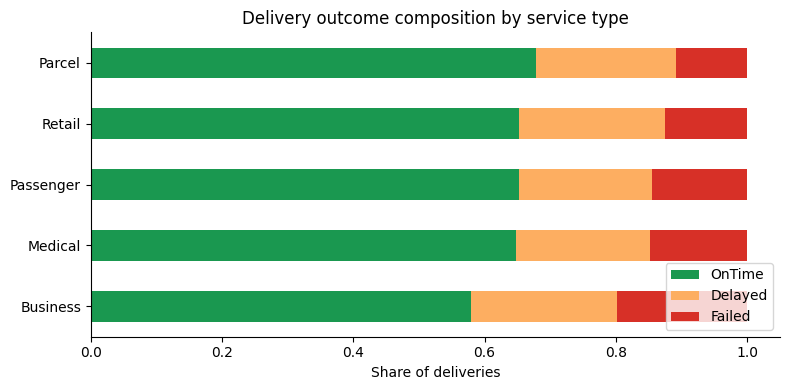

In [32]:
# 7.2 Stacked bar — outcome composition by service type
comp = (master.dropna(subset=['delivery_status'])
             .groupby('service_type')['delivery_status']
             .value_counts(normalize=True).unstack().fillna(0)
             [['OnTime','Delayed','Failed']]
             .sort_values('Failed', ascending=False))
ax = comp.plot(kind='barh', stacked=True, figsize=(8, 4),
               color=['#1a9850','#fdae61','#d73027'])
ax.set_xlabel('Share of deliveries'); ax.set_ylabel('')
ax.set_title('Delivery outcome composition by service type')
ax.legend(title='', loc='lower right')
plt.tight_layout()
plt.savefig(FIG/'02_outcome_by_service.png', dpi=120, bbox_inches='tight')
plt.show()

In [33]:
# 6.4 Battery vs maintenance (Tech Director's claim)
batt = (vehicles.assign(low_batt = vehicles['battery_health_pct'] < 50)
                .groupby('maintenance_status')
                .agg(n=('vehicle_id','count'),
                     mean_battery=('battery_health_pct','mean'),
                     min_battery=('battery_health_pct','min'),
                     pct_low=('low_batt', 'mean'))
                .round(2))
batt

,n,mean_battery,min_battery,pct_low
maintenance_status,,,,
Active,67,76.63,42.0,0.03
InRepair,36,76.64,47.6,0.03
Scheduled,17,77.67,65.5,0.00


## 7. Visualisations

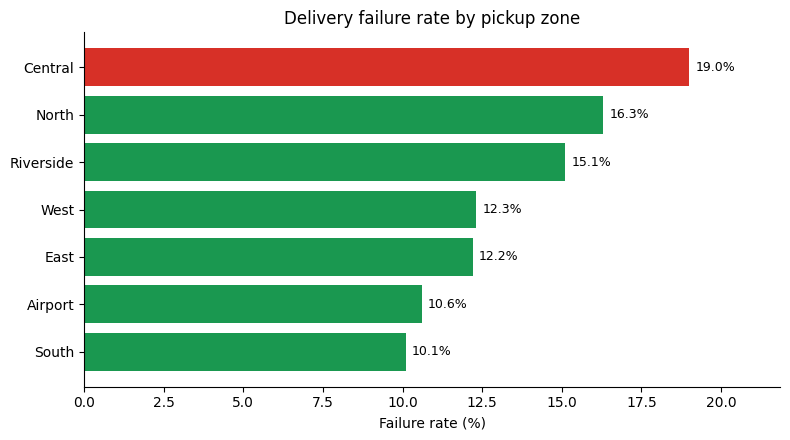

In [34]:
# 7.1 Bar chart — failure rate by zone, ordered
fig, ax = plt.subplots(figsize=(8,4.5))
data = zone_perf['Failed'].sort_values(ascending=True) * 100
colors = ['#1a9850']*len(data); colors[-1] = '#d73027'  # highlight worst
ax.barh(data.index, data.values, color=colors)
for i, v in enumerate(data.values):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Failure rate (%)'); ax.set_title('Delivery failure rate by pickup zone')
ax.set_xlim(0, max(data.values)*1.15)
plt.tight_layout()
plt.savefig(FIG/'01_failure_by_zone.png', dpi=120, bbox_inches='tight')
plt.show()

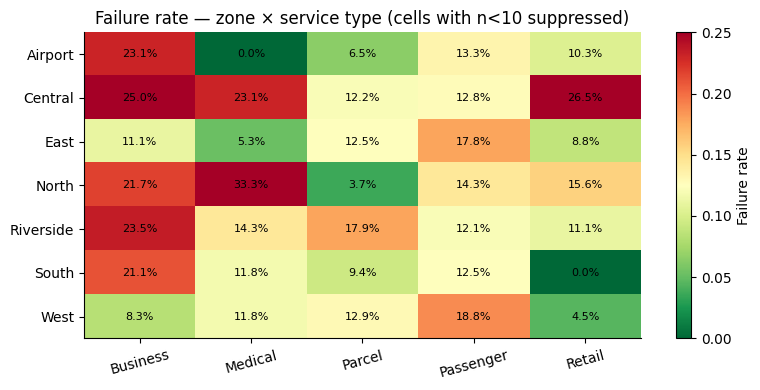

In [35]:
# 7.3 Heatmap — failure rate (zone × service)
hm = (master.dropna(subset=['delivery_status'])
            .groupby(['pickup_zone','service_type'])
            .agg(failure=('delivery_status', lambda x:(x=='Failed').mean()),
                 n=('delivery_status','size'))
            .reset_index())
hm.loc[hm['n']<10, 'failure'] = np.nan       # suppress small cells
pivot = hm.pivot(index='pickup_zone', columns='service_type', values='failure')
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=0.25)
ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels(pivot.columns, rotation=15)
ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i,j]
        ax.text(j, i, '–' if pd.isna(v) else f'{v*100:.1f}%',
                ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Failure rate')
ax.set_title('Failure rate — zone × service type (cells with n<10 suppressed)')
plt.tight_layout()
plt.savefig(FIG/'03_heatmap_zone_service.png', dpi=120, bbox_inches='tight')
plt.show()

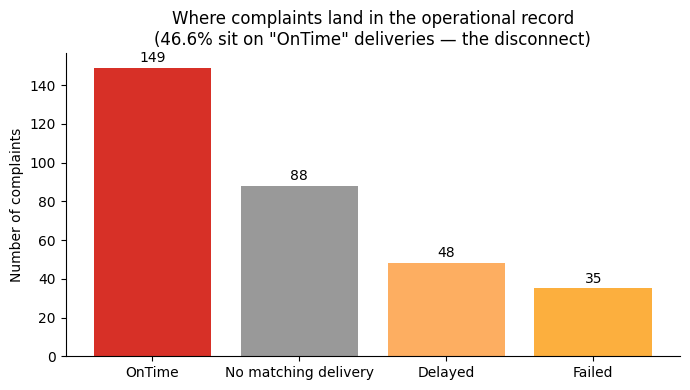

In [36]:
# 7.4 Hidden complaints visual — where do complaints land
fig, ax = plt.subplots(figsize=(7, 4))
vals = co['delivery_status'].fillna('No matching delivery').value_counts()
colors_map = {'OnTime':'#d73027','Delayed':'#fdae61','Failed':'#fcaf3e','No matching delivery':'#999'}
ax.bar(vals.index, vals.values, color=[colors_map.get(x,'#666') for x in vals.index])
for i, v in enumerate(vals.values):
    ax.text(i, v+3, str(v), ha='center', fontsize=10)
ax.set_ylabel('Number of complaints')
ax.set_title('Where complaints land in the operational record\n(46.6% sit on "OnTime" deliveries — the disconnect)')
plt.tight_layout()
plt.savefig(FIG/'04_hidden_complaints.png', dpi=120, bbox_inches='tight')
plt.show()

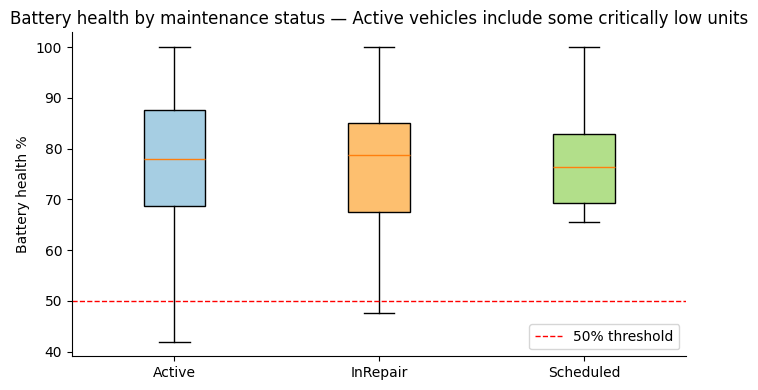

In [37]:
# 7.5 Battery health distribution by maintenance_status
fig, ax = plt.subplots(figsize=(7,4))
groups = vehicles.groupby('maintenance_status')['battery_health_pct']
labels, data = list(groups.groups.keys()), [groups.get_group(g).dropna().values for g in groups.groups.keys()]
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True)
for patch, c in zip(bp['boxes'], ['#a6cee3','#fdbf6f','#b2df8a']):
    patch.set_facecolor(c)
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_ylabel('Battery health %')
ax.set_title('Battery health by maintenance status — Active vehicles include some critically low units')
ax.legend()
plt.tight_layout()
plt.savefig(FIG/'05_battery_by_status.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Correlation snapshot

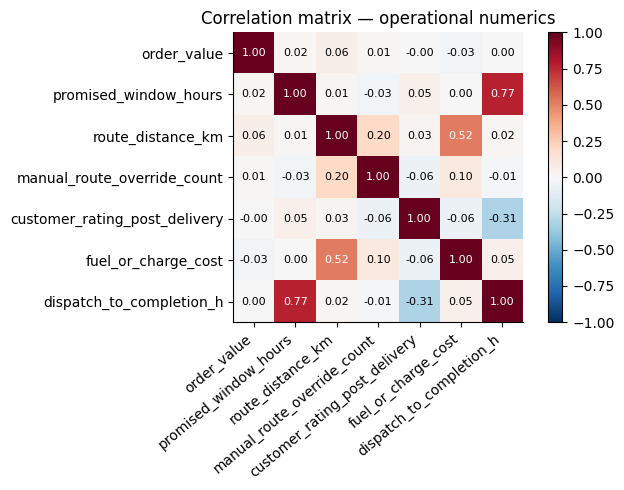

In [38]:
num_cols = ['order_value','promised_window_hours','route_distance_km',
            'manual_route_override_count','customer_rating_post_delivery',
            'fuel_or_charge_cost','dispatch_to_completion_h']
cm = master[num_cols].corr().round(2)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=40, ha='right')
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.index)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f'{cm.values[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(cm.values[i,j])>0.5 else 'black')
fig.colorbar(im, ax=ax)
ax.set_title('Correlation matrix — operational numerics')
plt.tight_layout()
plt.savefig(FIG/'06_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Export clean tables for downstream use

In [39]:
# Cleaned versions, ready for MongoDB & R
for name, df in [('hubs',hubs),('customers',customers),('drivers',drivers),
                 ('vehicles',vehicles),('orders',orders),('deliveries',deliveries),
                 ('incidents',incidents),('complaints',complaints),
                 ('app_events',app_events)]:
    df.to_csv(OUT/f'{name}_clean.csv', index=False)

# Master analytical frame
master.to_csv(OUT/'master_analytical.csv', index=False)

# Save data-quality report and a small JSON summary for the report
missing_report.to_csv(OUT/'_missing_report.csv', index=False)

summary = {
    'records':           {k: int(len(v)) for k,v in raw.items()},
    'failure_pct_total': float(round(
        (master['delivery_status']=='Failed').mean()*100, 2)),
    'pct_complaints_on_ontime': float(round(
        (co['delivery_status']=='OnTime').mean()*100, 2)),
    'order_value_at_risk_gbp': float(round(master['value_at_risk'].sum(), 2)),
    'compensation_paid_gbp':   float(round(complaints['compensation_amount'].sum(skipna=True), 2)),
}
with open(OUT/'_summary.json','w') as f:
    json.dump(summary, f, indent=2)
summary

{'records': {'hubs': 8,
  'customers': 650,
  'drivers': 170,
  'vehicles': 120,
  'orders': 1250,
  'deliveries': 950,
  'incidents': 280,
  'complaints': 320,
  'app_events': 640},
 'failure_pct_total': 10.56,
 'pct_complaints_on_ontime': 46.56,
 'order_value_at_risk_gbp': 29975.83,
 'compensation_paid_gbp': 6158.19}

## 10. Conclusions

1. **The Operations Director is partly right** — Central zone is genuinely the worst performer (19% failure, 51.7% on-time) — but the explanation is *not* hub capacity: H05 has the highest capacity score (88) and the second-worst failure rate (20%).
2. **The Customer Experience Director's data-disconnect claim is confirmed numerically.** 46.6% of complaints (149/320) are filed against deliveries the operational system marks `OnTime`. This is a system integration failure, not a customer behaviour pattern.
3. **The Finance Director is right that revenue is leaking.** £14,569 of revenue (12.8%) is tied to Delayed or Failed deliveries; an additional £6,158 has already been paid out as complaint compensation.
4. **The Technology Director is right about the data model.** Battery health is below 50% in some `Active` vehicles — the relational model can't easily express the time-ordered sensor stream that would catch this earlier. This is the case for the MongoDB redesign in the next notebook.
5. The clean datasets in `clean/` are now used by the MongoDB notebook (`03_mongodb_design.ipynb`).